<!--
  ============================================================================
  Section_J_theoretical_validation.ipynb  —  reproducibility notebook
  Section J of the Supplementary Materials
  ============================================================================
-->

<h1 align="center">Empirical Analysis of Variational Risk Bounds under &alpha;-Renyi Divergence</h1>

<p align="center">
  <b>Reproducibility for the empirical validation of the variational risk bounds in Section J of the Supplementary Materials</b><br>
  <i>Laplace Type I SSG &middot; Negative-Binomial Type II SSG &middot; six values of &alpha; &lt; 1 at two sample sizes</i>
</p>

<p align="center">
  <img alt="Python" src="https://img.shields.io/badge/Python-3.13-3776AB?logo=python&logoColor=white">
  <img alt="Jupyter" src="https://img.shields.io/badge/Jupyter-Notebook-F37626?logo=jupyter&logoColor=white">
  <img alt="TAVIE" src="https://img.shields.io/badge/TAVIE-module-1E4C7E">
</p>

<p align="center">
  <a href="https://github.com/Roy-SR-007/TAVIE-SSG/blob/main/Section_J_theoretical_validation.ipynb"><img alt="nbviewer" src="https://img.shields.io/badge/render-nbviewer-F37726?logo=jupyter&logoColor=white"></a>
  <img alt="Data" src="https://img.shields.io/badge/data-simulated-005EA2">
</p>

---

### What this notebook does

This notebook checks the **variational risk bounds** of Section J empirically. For each
setting it fits TAVIE-SSG to simulated data, estimates the mean $\alpha$-Renyi divergence
between the fitted and the true conditional laws by Monte Carlo integration over the
Normal&ndash;Gamma variational posterior, evaluates the theoretical upper bound at the
optimal $D$ and $\varepsilon$, and plots the gap between the two across the grid of
$\alpha < 1$.

Both SSG types are covered: the first half of the notebook treats the **Laplace** Type I
likelihood, the second half the **Negative-Binomial** Type II likelihood, each at two
sample sizes.

| | Specification |
|:--|:--|
| **Quantity** | mean $\alpha$-Renyi divergence between the fitted and true conditional laws, against its theoretical upper bound |
| **Laplace half** | Laplace Type I SSG likelihood with $\tau^{2} = 8.0$ |
| **Negative-Binomial half** | Negative-Binomial Type II SSG likelihood with $r = 10$ |
| **Design** | $n \in \{2000,\ 10000\}$, $p = 9$ including the intercept |
| **Divergence order** | $\alpha \in \{0.2,\ 0.3,\ 0.4,\ 0.6,\ 0.8,\ 0.95\}$ |
| **Monte Carlo** | 50 repetitions per setting, with 100 draws per divergence integral |
| **Bound constants** | $D$ and $\varepsilon$ selected by `choose_D_and_eps` at $c = 0.05$ |
| **Local module** | `TAVIE` |

> [!IMPORTANT]
> **To reproduce, run every cell in order, top to bottom.**

### Results generated in this notebook

| Main Manuscript | Supplementary Materials | Output file |
|:--:|:--:|:--|
| — | **Figure 19** | `variational_risk_bound_gap_Laplace_n_10000_p_8.pdf` |
| — | **Figure 18** | `variational_risk_bound_gap_Laplace_n_2000_p_8.pdf` |
| — | **Figure 20** | `variational_risk_bound_gap_NB_alpha_less_1_n_2000_p_8.pdf` |
| — | **Figure 21** | `variational_risk_bound_gap_NB_alpha_less_1_n_10000_p_8.pdf` |

All figures are written to `results_theory/plots/`, and the per-setting `results_*` and
`summary_*` pickles to `results_theory/`.

### For Laplace

In [1]:
# Required imports
import numpy as np
from TAVIE import *
import pandas as pd
import rich
from sklearn.preprocessing import scale
from IPython.display import display, Latex
import matplotlib.pyplot as plt

### Auxiliary Function for Laplace

In [2]:
def renyi_divergence_laplace(mu1, tau1, mu2, tau2, alpha, *, atol=1e-12):
    """
    Compute D_alpha(P || Q): alpha-Renyi divergence where
      P ~ Laplace(mu1, tau1),  Q ~ Laplace(mu2, tau2),  tau1>0, tau2>0, 0 < alpha < 1.
    """
    b1 = 1 / tau1
    b2 = 1 / tau2
    
    if b1 <= 0 or b2 <= 0:
        raise ValueError("Scales b1 and b2 must be positive.")
    if alpha <= 0:
        raise ValueError("alpha must be > 0.")
    if np.isclose(alpha, 1.0, atol=atol):
        raise ValueError("alpha=1 is the KL case; not handled in this function.")

    Delta = abs(mu1 - mu2)
    a = alpha / b1
    c = (1.0 - alpha) / b2

    # Common factors
    pow_factor = (1.0 / (2.0 * b1)) ** alpha * (1.0 / (2.0 * b2)) ** (1.0 - alpha)
    e_c = np.exp(-c * Delta)
    e_a = np.exp(-a * Delta)

    denom_sum = a + c
    if np.isclose(denom_sum, 0.0, atol=atol):
        # In theory with b1,b2>0 and alpha>0 this won’t hit, but keep guard anyway.
        raise ValueError("Encountered a+c ≈ 0, expression undefined.")

    term1 = (e_c + e_a) / denom_sum

    # Handle the (a - c) denominator with continuity at a==c
    if np.isclose(a - c, 0.0, atol=atol):
        term2 = Delta * e_c   # limit as a -> c
    else:
        term2 = (e_c - e_a) / (a - c)

    Z = pow_factor * (term1 + term2)

    if Z <= 0 or not np.isfinite(Z):
        raise ValueError("Integral term became non-positive or non-finite; check inputs.")

    return (1.0 / (alpha - 1.0)) * np.log(Z)

In [3]:
def mean_Dalpha_vec(X, beta, beta0, tau, tau0, alpha):
    """
    Compute the mean alpha-Rényi divergence between elementwise Laplace(Xbeta[i], tau)
    and Laplace(Xbeta0[i], tau0), using the renyi_divergence_laplace() function.
    """
    Xbeta = (np.asarray(X) @ np.asarray(beta)).ravel()
    Xbeta0 = (np.asarray(X) @ np.asarray(beta0)).ravel()
    # if mu1_vec.shape != mu2_vec.shape:
    #     raise ValueError("mu1_vec and mu2_vec must have the same length")

    divergences = np.array([
        renyi_divergence_laplace(Xbeta[i], tau, Xbeta0[i], tau0, alpha)
        for i in range(len(Xbeta))
    ])
    return np.mean(divergences)

In [4]:
def sample_normal_gamma(mu, Sigma, a, b, N, rng=None):
    """
    Draw N samples from:
        tau2 ~ Gamma(shape=a/2, scale=2/b)
        beta | tau2 ~ N(mu, Sigma / tau2)
    """
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)
    d = mu.shape[0]

    if rng is None:
        rng = np.random.default_rng()

    # 1) Draw tau^2 ~ Gamma(shape=a/2, scale=2/b)
    shape = a / 2.0
    scale = 2.0 / b
    tau2_samples = rng.gamma(shape=shape, scale=scale, size=N)  # (N,)

    # 2) Draw beta | tau^2
    # Cholesky of Sigma (d x d); Z ~ N(0, I_d)
    L = np.linalg.cholesky(Sigma)
    Z = rng.standard_normal(size=(N, d))
    # scale each row by 1/sqrt(tau2)
    inv_sqrt_tau2 = 1.0 / np.sqrt(tau2_samples)                 # (N,)
    beta_samples = mu + (Z @ L.T) * inv_sqrt_tau2[:, None]      # (N,d)

    return beta_samples, tau2_samples

In [5]:
def Dalpha_MC_integral(mu, Sigma, a, b, alpha, beta0, XX, tau0, N, rng=None):
    """
    Monte Carlo estimate of (1 - alpha) * E_beta[ Dalpha_beta_beta0(beta, beta0, XX, alpha, tau) ],
    where beta|tau2 ~ N(mu, Sigma/tau2) and tau2 ~ Gamma(shape = a/2, scale = 2/b).
    """
    mu    = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)
    beta0 = np.asarray(beta0, dtype=float)
    XX    = np.asarray(XX, dtype=float)

    if rng is None:
        rng = np.random.default_rng()

    # Draw samples from the Normal–Gamma hierarchy
    beta_samples, tau2_samples = sample_normal_gamma(mu, Sigma, a, b, N, rng=rng)

    vals = []
    for beta_i, tau2_i in zip(beta_samples, tau2_samples):
        tau_i = np.sqrt(tau2_i)  # since we sampled tau^2
        vals.append(
            mean_Dalpha_vec(XX, beta_i, beta0, tau_i, tau0, alpha)
        )

    return (1.0 - alpha) * float(np.mean(vals))

In [6]:
def choose_D_and_eps(C1, alpha, p, n, c=0.05, nudge=1e-12):
    # ---- Step 1: smallest feasible D
    const = (3 * (2**(2/3)) / c) ** 3  # ~ 864000 for c=0.05
    # ensure at least D=2
    D = max(2, 1 + int(np.ceil(np.sqrt(const / n))))

    # ---- Step 2: unconstrained minimizer for this D
    eps_star = np.sqrt((C1 * (p / n)) / (2.0 * D * alpha))

    # ---- Step 3: feasible interval from cubic 4 e^3 - c e^2 + 1/t = 0
    t = (D - 1.0) ** 2 * n
    coeffs = [4.0, -c, 0.0, 1.0 / t]
    roots = np.roots(coeffs)
    pos_real = sorted(r.real for r in roots if np.isreal(r) and r.real > 0)

    # If numerics return <2 positives (shouldn't happen), fall back to eps at g-minimum:
    if len(pos_real) < 2:
        eps_min = (1.0 / (2.0 * t)) ** (1.0 / 3.0)  # where g'(eps)=0
        # tiny nudge to satisfy strict inequality g(eps) < c
        return D, float(eps_min * (1 + 1e-12)), float(eps_star), (None, None)

    eps_low, eps_high = pos_real[0], pos_real[1]

    # Project eps_star into (eps_low, eps_high) and nudge off the boundary
    if eps_star <= eps_low:
        eps = np.nextafter(eps_low, eps_high)
    elif eps_star >= eps_high:
        eps = np.nextafter(eps_high, eps_low)
    else:
        eps = eps_star

    return D, float(eps)

In [7]:
from scipy.stats import gamma

def renyi_upper_bound_laplace(X, y, beta0, tau0, mu, Sigma, a, b, alpha):
    
    n, p = X.shape
    
    cons = 2
    E1 = 1
    E2 = 2
    E4 = 24
    
    K = 1
    M = np.max(1 / (4 * np.pow((np.sqrt(tau0) * (np.asarray(y) - np.asarray(X) @ np.asarray(beta0))).ravel(), 3))) + cons
    
    Q_tilde = 8 * max(1, K, K * E1, np.sqrt(M * E4), np.pow(M, 1/6), np.pow(M, 1/4), np.sqrt(M * E2))
    
    Q = np.max(np.linalg.norm(X, axis=1)) * max(tau0, 1 / (tau0 ** 2)) * Q_tilde
    
    diff = beta0 - mu
    Delta2 = float(diff.T @ np.linalg.solve(Sigma, diff))
    
    C = gamma.pdf(tau0, a=a/2, scale=2/b)

    
    Sigma_lambda_max = np.max(np.real(np.linalg.eigvals(Sigma)))
    
    C1 = 6 + np.log(np.sqrt(4 * Sigma_lambda_max) * (C / np.sqrt(tau0))) + ((tau0 + 1 / Q) * (Delta2 + 1 / (Q ** 2)))
    
    D, epsilon = choose_D_and_eps(C1, alpha, p, n, c=0.05, nudge=1e-12)
    
    bound = ((p * np.log(p)) / n) + (D * alpha * (epsilon ** 2)) + (C1 * (p / n) * np.log(1 / epsilon))
    
    return bound

### n = 10000, p = 9 (includes intercept), Laplace, n_MC = 100, nreps = 50, tau2 = 8, alphas = [0.2, 0.3, 0.4, 0.6, 0.8, 0.95]

See: `results_theory/results_Laplace_theory_alpha_less_1_n_10000_p_8.pkl` and `results_theory/summary_Laplace_theory_alpha_less_1_n_10000_p_8.pkl`

In [ ]:
import time

# --------------------------
# User-configurable settings
# --------------------------
nreps  = 50
n      = 10_000
n_MC   = 100
total_p = 9 # total_p = p+1
p      = 8
tau2   = 8.0
alphas = [0.2, 0.3, 0.4, 0.6, 0.8, 0.95]
rng    = np.random.default_rng(2025)  # global RNG (reproducible)

# --------------------------
# Helper: one repetition
# --------------------------
def run_one_rep(alpha, n, p, tau2, rng):
    """
    Returns a dict with: alpha, integral, bound, runtime_fit, n, p, tau2.
    """
    t0 = time.time()

    # --- Simulate data ---
    X = rng.normal(size=(n, p))                   # (n,p)
    X_bbvi = np.column_stack([np.ones(n), X])     # add intercept
    beta_true = rng.normal(loc=0.0, scale=1.0, size=p+1)  # (p+1,)
    # Laplace noise with scale = 1/sqrt(tau2)
    error = rng.laplace(loc=0.0, scale=1.0/np.sqrt(tau2), size=n)
    y = beta_true[0] + X @ beta_true[1:] + error

    # --- Fit TAVIE Laplace model ---
    t_fit0 = time.time()
    laplace_model = TAVIE_loc_scale(family="laplace", fit_intercept=True)
    laplace_model.fit(X, y, alpha=alpha, verbose=False)
    t_fit1 = time.time()
    runtime_fit = t_fit1 - t_fit0

    # --- Extract variational estimates ---
    variational_estimates = laplace_model.get_variational_estimates()
    # Expected keys: 'm_xi' (mean), 'V_xi' (cov), 'a_xi' (shape-like), 'b_xi' (rate/scale-like)

    # --- Monte Carlo integral ---
    integral = Dalpha_MC_integral(
        variational_estimates['m_xi'],
        variational_estimates['V_xi'],
        variational_estimates['a_xi'],
        variational_estimates['b_xi'],
        alpha=alpha,
        beta0=beta_true,
        XX=X_bbvi,
        tau0=np.sqrt(tau2),   # NOTE: if your mean_Dalpha_vec expects Laplace SCALE, use sqrt(tau2)
        N=n_MC,
        rng=rng
    )

    # --- Rényi upper bound (your function) ---
    bound = renyi_upper_bound_laplace(
        X_bbvi, y, beta_true, tau2,
        mu=np.zeros(p+1),
        Sigma=np.eye(p+1),
        a=0.05, b=0.05,
        alpha=alpha
    )

    return {
        "alpha": alpha,
        "integral": float(integral),
        "bound": float(bound),
        "runtime_fit": float(runtime_fit),
        "n": n,
        "p": p,
        "tau2": float(tau2),
    }

# --------------------------
# Main simulation loop
# --------------------------
records = []
for alpha in alphas:
    for rep in range(1, nreps + 1):
        rec = run_one_rep(alpha, n, p, tau2, rng)
        rec["rep"] = rep
        records.append(rec)

results = pd.DataFrame.from_records(records)

# Per-alpha summary
summary = (
    results
    .groupby("alpha", as_index=False)
    .agg(mean_integral=("integral", "mean"),
         sd_integral=("integral", "std"),
         mean_bound=("bound", "mean"),
         sd_bound=("bound", "std"),
         mean_runtime_fit=("runtime_fit", "mean"))
    .sort_values("alpha")
)

# (Optional) print a compact report
print("\nPer-alpha summary:")
print(summary.to_string(index=False))

# You now have:
# - 'results': one row per rep per alpha
# - 'summary': averages and std devs by alpha

results.to_pickle(f"results_theory/results_Laplace_theory_alpha_less_1_n_{n}_p_{p}.pkl")
summary.to_pickle(f"results_theory/summary_Laplace_theory_alpha_less_1_n_{n}_p_{p}.pkl")



Per-alpha summary:
 alpha  mean_integral  sd_integral  mean_bound  sd_bound  mean_runtime_fit
  0.20       0.000283     0.000094    0.284249  0.120679          0.092933
  0.30       0.000291     0.000119    0.299837  0.168487          0.098464
  0.40       0.000246     0.000068    0.285044  0.154307          0.102419
  0.60       0.000197     0.000070    0.302994  0.180497          0.112942
  0.80       0.000122     0.000050    0.303054  0.120605          0.111287
  0.95       0.000029     0.000012    0.283031  0.127247          0.119062


### Figure 19 of Supplementary Materials

See: `results_theory/plots/variational_risk_bound_gap_Laplace_n_10000_p_8.pdf`

gap range: [0.0458, 0.9799] | negative gaps: 0/300


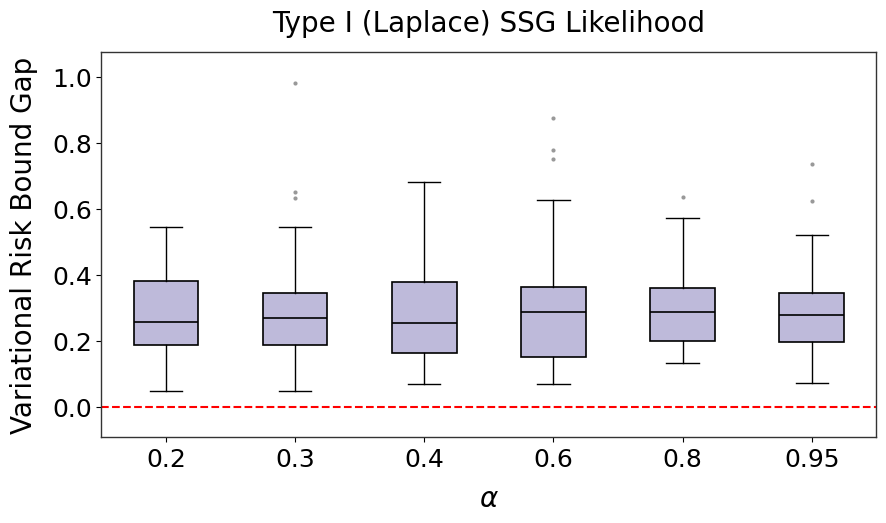

Saved Figure 19 to: results_theory/plots/variational_risk_bound_gap_Laplace_n_10000_p_8.pdf


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FIGURE 19 SETTINGS
# ============================================================
output_dir = "results_theory"
plot_dir = os.path.join(output_dir, "plots")
total_p = 9 # total_p = p + 1, where p is the number of covariates (excluding intercept)
n, p = 10000, 8

results_path = os.path.join(
    output_dir, f"results_Laplace_theory_alpha_less_1_n_{n}_p_{p}.pkl"
)
figure_path = os.path.join(
    plot_dir, f"variational_risk_bound_gap_Laplace_n_{n}_p_{p}.pdf"
)
os.makedirs(plot_dir, exist_ok=True)

# ============================================================
# LOAD SAVED SIMULATION RESULTS
# ============================================================
if not os.path.exists(results_path):
    raise FileNotFoundError(
        f"Saved results were not found:\n{results_path}\n"
        "Run the n=10000 Laplace simulation cell first."
    )
results = pd.read_pickle(results_path)

missing_columns = {"alpha", "bound", "integral"}.difference(results.columns)
if missing_columns:
    raise ValueError(f"The saved results are missing columns: {sorted(missing_columns)}")

# ============================================================
# PREPARE BOXPLOT DATA
# ============================================================
df = results.copy()
df["diff"] = df["bound"] - df["integral"]

alphas = np.sort(df["alpha"].dropna().unique())
if alphas.size == 0:
    raise ValueError("No non-missing alpha values in the saved results.")

data_by_alpha, kept_alphas = [], []
for alpha in alphas:
    vals = df.loc[df["alpha"] == alpha, "diff"].dropna().to_numpy()
    if vals.size == 0:
        print(f"[warn] alpha={alpha:g}: no finite differences, skipping.")
        continue
    data_by_alpha.append(vals)
    kept_alphas.append(alpha)
if not data_by_alpha:
    raise ValueError("Every alpha group was empty after dropping NaNs.")

# ============================================================
# FONT SIZES
# ============================================================
label_fontsize, tick_fontsize, title_fontsize = 20, 18, 20

# ============================================================
# CREATE FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")

bp = ax.boxplot(
    data_by_alpha,
    tick_labels=[f"{a:g}" for a in kept_alphas],
    showfliers=True,
    patch_artist=True,
)

# ============================================================
# BOXPLOT STYLE
# ============================================================
for box in bp["boxes"]:
    box.set(facecolor="#BEBADA", edgecolor="black", linewidth=1.2)
for median in bp["medians"]:
    median.set(color="black", linewidth=1.2)
for artist in bp["whiskers"] + bp["caps"]:
    artist.set(color="black", linewidth=1.0)
for flier in bp["fliers"]:
    flier.set(marker="o", markersize=3, markerfacecolor="#555555",
              markeredgecolor="none", alpha=0.6)

# ============================================================
# REFERENCE LINE AND AXIS LIMITS
# ============================================================
ax.axhline(0.0, color="red", linestyle="--", linewidth=1.5, zorder=0)

all_differences = np.concatenate(data_by_alpha)
ymin, ymax = float(all_differences.min()), float(all_differences.max())
span = ymax - ymin
padding = 0.1 * span if span > 0 else 0.1 * max(abs(ymax), 1.0)
ax.set_ylim(min(ymin - padding, -padding), ymax + padding)   # never clips data

n_neg = int((all_differences < 0).sum())
print(f"gap range: [{ymin:.4g}, {ymax:.4g}] | negative gaps: {n_neg}/{all_differences.size}")

# ============================================================
# LABELS AND TITLE
# ============================================================
ax.set_xlabel(r"$\alpha$", fontsize=label_fontsize, labelpad=10)
ax.set_ylabel("Variational Risk Bound Gap", fontsize=label_fontsize, labelpad=10)
ax.set_title("Type I (Laplace) SSG Likelihood", fontsize=title_fontsize, pad=15)
ax.tick_params(axis="both", which="major", labelsize=tick_fontsize)
ax.set_facecolor("white")
for spine in ax.spines.values():
    spine.set_color("#333333")
    spine.set_linewidth(1.0)

# ============================================================
# SAVE AS PDF
# ============================================================
fig.savefig(figure_path, format="pdf", bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved Figure 19 to: {figure_path}")

### n = 2000, p = 9 (includes intercept), Laplace, n_MC = 100, nreps = 50, tau2 = 8, alphas = [0.2, 0.3, 0.4, 0.6, 0.8, 0.95]

See: `results_theory/results_Laplace_theory_alpha_less_1_n_2000_p_8.pkl` and `results_theory/summary_Laplace_theory_alpha_less_1_n_2000_p_8.pkl`

In [ ]:
import time

# --------------------------
# User-configurable settings
# --------------------------
nreps  = 50
n      = 2000
n_MC   = 100
total_p = 9 # total_p = p + 1, where p is the number of covariates (excluding intercept)
p      = 8
tau2   = 8.0
alphas = [0.2, 0.3, 0.4, 0.6, 0.8, 0.95]
rng    = np.random.default_rng(2025)  # global RNG (reproducible)

# --------------------------
# Helper: one repetition
# --------------------------
def run_one_rep(alpha, n, p, tau2, rng):
    """
    Returns a dict with: alpha, integral, bound, runtime_fit, n, p, tau2.
    """
    t0 = time.time()

    # --- Simulate data ---
    X = rng.normal(size=(n, p))                   # (n,p)
    X_bbvi = np.column_stack([np.ones(n), X])     # add intercept
    beta_true = rng.normal(loc=0.0, scale=1.0, size=p+1)  # (p+1,)
    # Laplace noise with scale = 1/sqrt(tau2)
    error = rng.laplace(loc=0.0, scale=1.0/np.sqrt(tau2), size=n)
    y = beta_true[0] + X @ beta_true[1:] + error

    # --- Fit TAVIE Laplace model ---
    t_fit0 = time.time()
    laplace_model = TAVIE_loc_scale(family="laplace", fit_intercept=True)
    laplace_model.fit(X, y, alpha=alpha, verbose=False)
    t_fit1 = time.time()
    runtime_fit = t_fit1 - t_fit0

    # --- Extract variational estimates ---
    variational_estimates = laplace_model.get_variational_estimates()
    # Expected keys: 'm_xi' (mean), 'V_xi' (cov), 'a_xi' (shape-like), 'b_xi' (rate/scale-like)

    # --- Monte Carlo integral ---
    integral = Dalpha_MC_integral(
        variational_estimates['m_xi'],
        variational_estimates['V_xi'],
        variational_estimates['a_xi'],
        variational_estimates['b_xi'],
        alpha=alpha,
        beta0=beta_true,
        XX=X_bbvi,
        tau0=np.sqrt(tau2),   # NOTE: if your mean_Dalpha_vec expects Laplace SCALE, use sqrt(tau2)
        N=n_MC,
        rng=rng
    )

    # --- Rényi upper bound (your function) ---
    bound = renyi_upper_bound_laplace(
        X_bbvi, y, beta_true, tau2,
        mu=np.zeros(p+1),
        Sigma=np.eye(p+1),
        a=0.05, b=0.05,
        alpha=alpha
    )

    return {
        "alpha": alpha,
        "integral": float(integral),
        "bound": float(bound),
        "runtime_fit": float(runtime_fit),
        "n": n,
        "p": p,
        "tau2": float(tau2),
    }

# --------------------------
# Main simulation loop
# --------------------------
records = []
for alpha in alphas:
    for rep in range(1, nreps + 1):
        rec = run_one_rep(alpha, n, p, tau2, rng)
        rec["rep"] = rep
        records.append(rec)

results = pd.DataFrame.from_records(records)

# Per-alpha summary
summary = (
    results
    .groupby("alpha", as_index=False)
    .agg(mean_integral=("integral", "mean"),
         sd_integral=("integral", "std"),
         mean_bound=("bound", "mean"),
         sd_bound=("bound", "std"),
         mean_runtime_fit=("runtime_fit", "mean"))
    .sort_values("alpha")
)

# (Optional) print a compact report
print("\nPer-alpha summary:")
print(summary.to_string(index=False))

# You now have:
# - 'results': one row per rep per alpha
# - 'summary': averages and std devs by alpha

results.to_pickle(f"results_theory/results_Laplace_theory_alpha_less_1_n_{n}_p_{p}.pkl")
summary.to_pickle(f"results_theory/summary_Laplace_theory_alpha_less_1_n_{n}_p_{p}.pkl")



Per-alpha summary:
 alpha  mean_integral  sd_integral  mean_bound  sd_bound  mean_runtime_fit
  0.20       0.002714     0.001918    1.486088  0.966063          0.014834
  0.30       0.002344     0.001024    1.624540  0.751379          0.015565
  0.40       0.001872     0.000805    1.575698  0.680653          0.017025
  0.60       0.001342     0.000548    1.515838  0.647190          0.018871
  0.80       0.000735     0.000244    1.583018  0.681874          0.020240
  0.95       0.000188     0.000070    1.394988  0.655544          0.021039


### Figure 18 of Supplementary Materials

See: `results_theory/plots/variational_risk_bound_gap_Laplace_n_2000_p_8.pdf`

/var/folders/ls/s91_zt990n9b6gdbr57m19900000gn/T/ipykernel_47200/2060066145.py:54: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(


gap range: [0.2638, 5.976] | negative gaps: 0/300


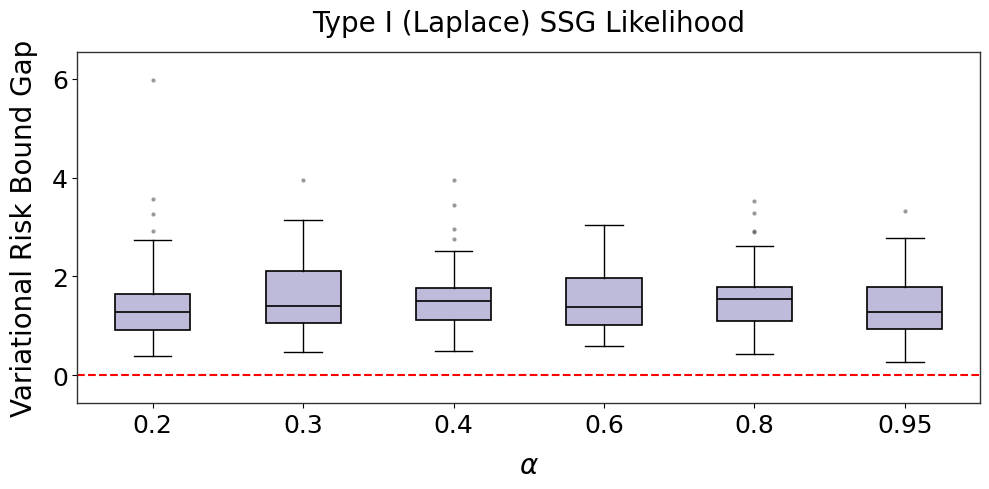

Saved Figure 18 to: results_theory/plots/variational_risk_bound_gap_Laplace_n_2000_p_8.pdf


In [ ]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# FIGURE 18 SETTINGS
# ============================================================

output_dir = "results_theory"
plot_dir = os.path.join(
    output_dir,
    "plots",
)

n = 2000
total_p = 9  # total_p = p + 1, where p is the number of covariates (excluding intercept)
p = 8

results_path = os.path.join(
    output_dir,
    f"results_Laplace_theory_alpha_less_1_n_{n}_p_{p}.pkl",
)

figure_path = os.path.join(
    plot_dir,
    f"variational_risk_bound_gap_Laplace_n_{n}_p_{p}.pdf",
)

os.makedirs(
    plot_dir,
    exist_ok=True,
)


# ============================================================
# NUMPY PICKLE COMPATIBILITY
#
# This handles files saved using NumPy 2.x when the current
# environment uses NumPy 1.x.
# ============================================================

class NumPyCompatibilityUnpickler(pickle.Unpickler):

    def find_class(self, module, name):
        if module.startswith("numpy._core"):
            module = (
                "numpy.core"
                + module[len("numpy._core"):]
            )

        return super().find_class(
            module,
            name,
        )


def read_numpy_compatible_pickle(path):
    with open(path, "rb") as file:
        return NumPyCompatibilityUnpickler(
            file
        ).load()


# ============================================================
# LOAD SAVED SIMULATION RESULTS
# ============================================================

if not os.path.exists(results_path):
    raise FileNotFoundError(
        f"Saved results were not found:\n{results_path}\n"
        "Run the n=2000 Laplace simulation cell first."
    )

results = read_numpy_compatible_pickle(
    results_path
)

if not isinstance(results, pd.DataFrame):
    results = pd.DataFrame(
        results
    )

required_columns = {
    "alpha",
    "bound",
    "integral",
}

missing_columns = required_columns.difference(
    results.columns
)

if missing_columns:
    raise ValueError(
        "The saved results are missing columns: "
        f"{sorted(missing_columns)}"
    )


# ============================================================
# PREPARE BOXPLOT DATA
# ============================================================

df = results.copy()

df["diff"] = (
    df["bound"]
    - df["integral"]
)

alphas = np.sort(
    df["alpha"].dropna().unique()
)

if alphas.size == 0:
    raise ValueError(
        "No non-missing alpha values were found "
        "in the saved results."
    )

data_by_alpha = []
kept_alphas = []

for alpha in alphas:
    values = (
        df.loc[
            df["alpha"] == alpha,
            "diff",
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .to_numpy(dtype=float)
    )

    if values.size == 0:
        print(
            f"[warn] alpha={alpha:g}: "
            "no finite differences; skipping."
        )
        continue

    data_by_alpha.append(
        values
    )

    kept_alphas.append(
        alpha
    )

if not data_by_alpha:
    raise ValueError(
        "Every alpha group was empty after removing "
        "NaN and infinite values."
    )


# ============================================================
# FONT SIZES
# ============================================================

label_fontsize = 20
tick_fontsize = 18
title_fontsize = 20


# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5),
    facecolor="white",
)

bp = ax.boxplot(
    data_by_alpha,
    tick_labels=[
        f"{alpha:g}"
        for alpha in kept_alphas
    ],
    showfliers=True,
    patch_artist=True,
)


# ============================================================
# BOXPLOT STYLE
# ============================================================

for box in bp["boxes"]:
    box.set(
        facecolor="#BEBADA",
        edgecolor="black",
        linewidth=1.2,
    )

for median in bp["medians"]:
    median.set(
        color="black",
        linewidth=1.2,
    )

for artist in (
    bp["whiskers"]
    + bp["caps"]
):
    artist.set(
        color="black",
        linewidth=1.0,
    )

for flier in bp["fliers"]:
    flier.set(
        marker="o",
        markersize=3,
        markerfacecolor="#555555",
        markeredgecolor="none",
        alpha=0.6,
    )


# ============================================================
# REFERENCE LINE AND AXIS LIMITS
# ============================================================

ax.axhline(
    0.0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    zorder=0,
)

all_differences = np.concatenate(
    data_by_alpha
)

ymin = float(
    all_differences.min()
)

ymax = float(
    all_differences.max()
)

span = ymax - ymin

padding = (
    0.1 * span
    if span > 0
    else 0.1 * max(abs(ymax), 1.0)
)

ax.set_ylim(
    min(ymin - padding, -padding),
    ymax + padding,
)

number_negative = int(
    (all_differences < 0).sum()
)

print(
    f"gap range: [{ymin:.4g}, {ymax:.4g}] | "
    f"negative gaps: {number_negative}/"
    f"{all_differences.size}"
)


# ============================================================
# LABELS AND TITLE
# ============================================================

ax.set_xlabel(
    r"$\alpha$",
    fontsize=label_fontsize,
    labelpad=10,
)

ax.set_ylabel(
    "Variational Risk Bound Gap",
    fontsize=label_fontsize,
    labelpad=10,
)

ax.set_title(
    "Type I (Laplace) SSG Likelihood",
    fontsize=title_fontsize,
    pad=15,
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=tick_fontsize,
)

ax.set_facecolor(
    "white"
)

for spine in ax.spines.values():
    spine.set_color(
        "#333333"
    )

    spine.set_linewidth(
        1.0
    )

fig.tight_layout()


# ============================================================
# SAVE FIGURE 18 AS PDF
# ============================================================

fig.savefig(
    figure_path,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(
    f"Saved Figure 18 to: {figure_path}"
)

### For Negative-Binomial

In [2]:
# Required imports
import numpy as np
from TAVIE import *
import pandas as pd
import rich
import time
from sklearn.preprocessing import scale
from IPython.display import display, Latex
import matplotlib.pyplot as plt

### Auxiliary Functions for Negative-Binomial

In [5]:
def renyi_divergence_nb_equal_r(r, p1, p2, alpha):
    z = (1 - p1)**alpha * (1 - p2)**(1 - alpha)
    num = 1 - z
    den = (p1 ** alpha) * (p2 ** (1-alpha))
    A = -np.log(num / den)
    return ((r / (alpha-1)) * A)

def mean_Dalpha_vec_nb(X, r, beta, beta0, alpha):
    Xbeta = (np.asarray(X) @ np.asarray(beta)).ravel()
    Xbeta0 = (np.asarray(X) @ np.asarray(beta0)).ravel()
    
    p = 1 / (1 + np.exp(-Xbeta))
    p0 = 1 / (1 + np.exp(-Xbeta0))
    # if mu1_vec.shape != mu2_vec.shape:
    #     raise ValueError("mu1_vec and mu2_vec must have the same length")

    divergences = np.array([
        renyi_divergence_nb_equal_r(r[i], p[i], p0[i], alpha)
        for i in range(len(Xbeta))
    ])
    return np.mean(divergences)


def Dalpha_MC_integral_nb(mu, Sigma, alpha, r, beta0, XX, N, rng=None):
    mu    = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)
    beta0 = np.asarray(beta0, dtype=float)
    XX    = np.asarray(XX, dtype=float)

    if rng is None:
        rng = np.random.default_rng()

    # Draw samples from the Normal
    beta_samples = np.random.multivariate_normal(mean=mu, cov=Sigma, size=N)
    vals = []
    for beta_i in beta_samples:
        vals.append(
            mean_Dalpha_vec_nb(XX, r*np.ones(XX.shape[0]), beta_i, beta0, alpha)
        )

    return (1.0 - alpha) * float(np.mean(vals))

### Variational Risk bound for optimal $D$ and $\varepsilon$

In [6]:
def choose_D_and_eps(C1, alpha, p, n, c=0.05, nudge=1e-12):
    # ---- Step 1: smallest feasible D
    const = (3 * (2**(2/3)) / c) ** 3  # ~ 864000 for c=0.05
    # ensure at least D=2
    D = max(2, 1 + int(np.ceil(np.sqrt(const / n))))

    # ---- Step 2: unconstrained minimizer for this D
    eps_star = np.sqrt((C1 * (p / n)) / (2.0 * D * alpha))

    # ---- Step 3: feasible interval from cubic 4 e^3 - c e^2 + 1/t = 0
    t = (D - 1.0) ** 2 * n
    coeffs = [4.0, -c, 0.0, 1.0 / t]
    roots = np.roots(coeffs)
    pos_real = sorted(r.real for r in roots if np.isreal(r) and r.real > 0)

    # If numerics return <2 positives (shouldn't happen), fall back to eps at g-minimum:
    if len(pos_real) < 2:
        eps_min = (1.0 / (2.0 * t)) ** (1.0 / 3.0)  # where g'(eps)=0
        # tiny nudge to satisfy strict inequality g(eps) < c
        return D, float(eps_min * (1 + 1e-12)), float(eps_star), (None, None)

    eps_low, eps_high = pos_real[0], pos_real[1]

    # Project eps_star into (eps_low, eps_high) and nudge off the boundary
    if eps_star <= eps_low:
        eps = np.nextafter(eps_low, eps_high)
    elif eps_star >= eps_high:
        eps = np.nextafter(eps_high, eps_low)
    else:
        eps = eps_star

    return D, float(eps)


def renyi_upper_bound_nb(X, r, beta0, mu, Sigma, alpha):
    
    n, p = X.shape
    
    X2_inf = np.max(np.linalg.norm(X, axis=1))
    beta0_l2 = np.linalg.norm(beta0)
    
    Q = max(4 * X2_inf, 8 * (X2_inf ** 2) * beta0_l2) * r * (1 + np.exp(X2_inf * beta0_l2))
    
    diff = beta0 - mu
    Delta2 = float(diff.T @ np.linalg.solve(Sigma, diff))
    
    Sigma_lambda_max = max(np.real(np.linalg.eigvals(Sigma)))
    
    C1 = 0.5 * (8 + np.log(2) + np.log(Sigma_lambda_max) + 2 * np.log(Q) + Delta2  + (1 / (Sigma_lambda_max * (Q ** 2))))
    
    D, epsilon = choose_D_and_eps(C1, alpha, p, n, c=0.05, nudge=1e-12)
    
    bound = ((p * np.log(p)) / n) + (D * alpha * (epsilon ** 2)) + (C1 * (p / n) * np.log(1 / epsilon))
    
    return bound

### Figure 20 of the Supplementary Materials

For $n=2000$, see: `results_theory/results_NB_theory_alpha_less_1_n_2000_p_8.pkl`, `results_theory/summary_NB_theory_alpha_less_1_n_2000_p_8.pkl`, and `results_theory/plots/variational_risk_bound_gap_NB_alpha_less_1_n_2000_p_8.pdf`

In [ ]:
import time

# --------------------------
# User-configurable settings
# --------------------------
nreps  = 50
n      = 2000
n_MC   = 100
total_p = 9 # total_p = p + 1, where p is the number of covariates (excluding intercept)
p      = 8
r      = 10
alphas = [0.2, 0.3, 0.4, 0.6, 0.8, 0.95]
rng    = np.random.default_rng(2025)  # global RNG (reproducible)

# --------------------------
# Helper: one repetition
# --------------------------
def run_one_rep(alpha, n, p, rng):
    """
    Returns a dict with: alpha, integral, bound, runtime_fit, n, p, tau2.
    """
    t0 = time.time()

    # --- Simulate data ---
    beta_true = np.random.normal(loc=0.0, scale=0.5, size=p+1)
    X = np.random.normal(size=(n, p))
    X_bbvi = np.column_stack((np.ones(n), X))
    linear_term  = beta_true[0] + X @ beta_true[1:len(beta_true)] 
    probs = 1 / (1 + np.exp(-linear_term))
    y = np.random.negative_binomial(r, probs, size=n)

    # --- Fit TAVIE Negbin model ---
    t_fit0 = time.time()
    negbin_tavie_model = TAVIE_type_II(family="negbin", fit_intercept=True)
    negbin_tavie_model.fit(X, y, r=r, alpha = alpha, verbose=False) # fitting the TAVIE model for laplace
    t_fit1 = time.time()
    runtime_fit = t_fit1 - t_fit0

    # --- Extract variational estimates ---
    variational_estimates = negbin_tavie_model.get_variational_estimates()
    # Expected keys: 'm_xi' (mean), 'V_xi' (cov), 'a_xi' (shape-like), 'b_xi' (rate/scale-like)

    # --- Monte Carlo integral ---
    integral = Dalpha_MC_integral_nb(
        variational_estimates['m_xi'],
        variational_estimates['V_xi'],
        alpha=alpha,
        r = r,
        beta0=beta_true,
        XX=X_bbvi,
        N=n_MC,
        rng=rng
    )

    # --- Rényi upper bound (your function) ---
    bound = renyi_upper_bound_nb(X_bbvi, 10, beta_true, 
                                 variational_estimates['m_xi'],  variational_estimates['V_xi'], 
                                 alpha)

    return {
        "alpha": alpha,
        "integral": float(integral),
        "bound": float(bound),
        "runtime_fit": float(runtime_fit),
        "n": n,
        "p": p,
    }

# --------------------------
# Main simulation loop
# --------------------------
records = []
for alpha in alphas:
    for rep in range(1, nreps + 1):
        rec = run_one_rep(alpha, n, p, rng)
        rec["rep"] = rep
        records.append(rec)
        print(f"alpha = {alpha}, rep = {rep}")
results = pd.DataFrame.from_records(records)

# Per-alpha summary
summary = (
    results
    .groupby("alpha", as_index=False)
    .agg(mean_integral=("integral", "mean"),
         sd_integral=("integral", "std"),
         mean_bound=("bound", "mean"),
         sd_bound=("bound", "std"),
         mean_runtime_fit=("runtime_fit", "mean"))
    .sort_values("alpha")
)

# (Optional) print a compact report
print("\nPer-alpha summary:")
print(summary.to_string(index=False))

# You now have:
# - 'results': one row per rep per alpha
# - 'summary': averages and std devs by alpha

results.to_pickle(f"results_theory/results_NB_theory_alpha_less_1_n_{n}_p_{p}.pkl")
summary.to_pickle(f"results_theory/summary_NB_theory_alpha_less_1_n_{n}_p_{p}.pkl")


# df = results.copy()
# df["diff"] = df["bound"] - df["integral"]

# # Sort alphas for consistent ordering
# alphas = np.sort(df["alpha"].unique())
# data_by_alpha = [df.loc[df["alpha"] == a, "diff"].to_numpy() for a in alphas]

# # Font sizes
# label_fontsize = 16
# tick_fontsize = 14
# title_fontsize = 18

# # Create figure
# fig, ax = plt.subplots(figsize=(10, 5))

# bp = ax.boxplot(
#     data_by_alpha,
#     labels=[str(a) for a in alphas],
#     showfliers=True,
#     patch_artist=True
# )

# # Light blue fill
# for box in bp['boxes']:
#     box.set(facecolor="#BEBADA", edgecolor="black", linewidth=1.2)

# # Bold black medians
# for median in bp['medians']:
#     median.set(color="black", linewidth=1.2)

# # Red dashed reference line at 0
# ax.axhline(0, color="red", linestyle="--", linewidth=1.5)

# ymin = min(np.concatenate(data_by_alpha))
# ymax = max(np.concatenate(data_by_alpha))
# pad = 0.1 * max(abs(ymin), abs(ymax))  # 10% padding
# lim = max(abs(ymin), abs(ymax)) + pad
# ax.set_ylim(-0.25, lim)

# # Axis labels and title with larger fonts
# ax.set_xlabel(r"$\alpha$", fontsize=label_fontsize, labelpad=10)
# ax.set_ylabel(r"Variational Risk Bound Gap", fontsize=label_fontsize, labelpad=10)
# ax.set_title(r"Type II (NB) SSG Likelihood", fontsize=title_fontsize, pad=15)

# # Tick label size
# ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

# fig.tight_layout()

# # Save figure
# fig.savefig(f"results_theory/variational_risk_bound_gap_NB_alpha_less_1_n_{n}_p_{p}.png", dpi=300, bbox_inches='tight')

# plt.show()


### Figure 21 of the Supplementary Materials

For $n=10000$, see: `results_theory/results_NB_theory_alpha_less_1_n_10000_p_8.pkl`, `results_theory/summary_NB_theory_alpha_less_1_n_10000_p_8.pkl`, and `results_theory/plots/variational_risk_bound_gap_NB_alpha_less_1_n_10000_p_8.pdf`

In [ ]:
import time

# --------------------------
# User-configurable settings
# --------------------------
nreps  = 50
n      = 10000
n_MC   = 100
total_p = 9 # total_p = p + 1, where p is the number of covariates (excluding intercept)
p      = 8
r      = 10
alphas = [0.2, 0.3, 0.4, 0.6, 0.8, 0.95]
rng    = np.random.default_rng(2025)  # global RNG (reproducible)

# --------------------------
# Helper: one repetition
# --------------------------
def run_one_rep(alpha, n, p, rng):
    """
    Returns a dict with: alpha, integral, bound, runtime_fit, n, p, tau2.
    """
    t0 = time.time()

    # --- Simulate data ---
    beta_true = np.random.normal(loc=0.0, scale=0.5, size=p+1)
    X = np.random.normal(size=(n, p))
    X_bbvi = np.column_stack((np.ones(n), X))
    linear_term  = beta_true[0] + X @ beta_true[1:len(beta_true)] 
    probs = 1 / (1 + np.exp(-linear_term))
    y = np.random.negative_binomial(r, probs, size=n)

    # --- Fit TAVIE Negbin model ---
    t_fit0 = time.time()
    negbin_tavie_model = TAVIE_type_II(family="negbin", fit_intercept=True)
    negbin_tavie_model.fit(X, y, r=r, alpha = alpha, verbose=False) # fitting the TAVIE model for laplace
    t_fit1 = time.time()
    runtime_fit = t_fit1 - t_fit0

    # --- Extract variational estimates ---
    variational_estimates = negbin_tavie_model.get_variational_estimates()
    # Expected keys: 'm_xi' (mean), 'V_xi' (cov), 'a_xi' (shape-like), 'b_xi' (rate/scale-like)

    # --- Monte Carlo integral ---
    integral = Dalpha_MC_integral_nb(
        variational_estimates['m_xi'],
        variational_estimates['V_xi'],
        alpha=alpha,
        r = r,
        beta0=beta_true,
        XX=X_bbvi,
        N=n_MC,
        rng=rng
    )

    # --- Rényi upper bound (your function) ---
    bound = renyi_upper_bound_nb(X_bbvi, 10, beta_true, 
                                 variational_estimates['m_xi'],  variational_estimates['V_xi'], 
                                 alpha)

    return {
        "alpha": alpha,
        "integral": float(integral),
        "bound": float(bound),
        "runtime_fit": float(runtime_fit),
        "n": n,
        "p": p,
    }

# --------------------------
# Main simulation loop
# --------------------------
records = []
for alpha in alphas:
    for rep in range(1, nreps + 1):
        rec = run_one_rep(alpha, n, p, rng)
        rec["rep"] = rep
        records.append(rec)
        print(f"alpha = {alpha}, rep = {rep}")
results = pd.DataFrame.from_records(records)

# Per-alpha summary
summary = (
    results
    .groupby("alpha", as_index=False)
    .agg(mean_integral=("integral", "mean"),
         sd_integral=("integral", "std"),
         mean_bound=("bound", "mean"),
         sd_bound=("bound", "std"),
         mean_runtime_fit=("runtime_fit", "mean"))
    .sort_values("alpha")
)

# (Optional) print a compact report
print("\nPer-alpha summary:")
print(summary.to_string(index=False))

# You now have:
# - 'results': one row per rep per alpha
# - 'summary': averages and std devs by alpha

results.to_pickle(f"results_theory/results_NB_theory_alpha_less_1_n_{n}_p_{p}.pkl")
summary.to_pickle(f"results_theory/summary_NB_theory_alpha_less_1_n_{n}_p_{p}.pkl")


# df = results.copy()
# df["diff"] = df["bound"] - df["integral"]

# # Sort alphas for consistent ordering
# alphas = np.sort(df["alpha"].unique())
# data_by_alpha = [df.loc[df["alpha"] == a, "diff"].to_numpy() for a in alphas]

# # Font sizes
# label_fontsize = 16
# tick_fontsize = 14
# title_fontsize = 18

# # Create figure
# fig, ax = plt.subplots(figsize=(10, 5))

# bp = ax.boxplot(
#     data_by_alpha,
#     labels=[str(a) for a in alphas],
#     showfliers=True,
#     patch_artist=True
# )

# # Light blue fill
# for box in bp['boxes']:
#     box.set(facecolor="#BEBADA", edgecolor="black", linewidth=1.2)

# # Bold black medians
# for median in bp['medians']:
#     median.set(color="black", linewidth=1.2)

# # Red dashed reference line at 0
# ax.axhline(0, color="red", linestyle="--", linewidth=1.5)

# ymin = min(np.concatenate(data_by_alpha))
# ymax = max(np.concatenate(data_by_alpha))
# pad = 0.1 * max(abs(ymin), abs(ymax))  # 10% padding
# lim = max(abs(ymin), abs(ymax)) + pad
# ax.set_ylim(-0.25, lim)

# # Axis labels and title with larger fonts
# ax.set_xlabel(r"$\alpha$", fontsize=label_fontsize, labelpad=10)
# ax.set_ylabel(r"Variational Risk Bound Gap", fontsize=label_fontsize, labelpad=10)
# ax.set_title(r"Type II (NB) SSG Likelihood", fontsize=title_fontsize, pad=15)

# # Tick label size
# ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

# fig.tight_layout()

# # Save figure
# fig.savefig(f"results_theory/variational_risk_bound_gap_NB_alpha_less_1_n_{n}_p_{p}.png", dpi=300, bbox_inches='tight')

# plt.show()


/var/folders/ls/s91_zt990n9b6gdbr57m19900000gn/T/ipykernel_47200/2883230770.py:52: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(


Figure 20: gap range = [0.2803, 0.9114] | negative gaps = 0/300


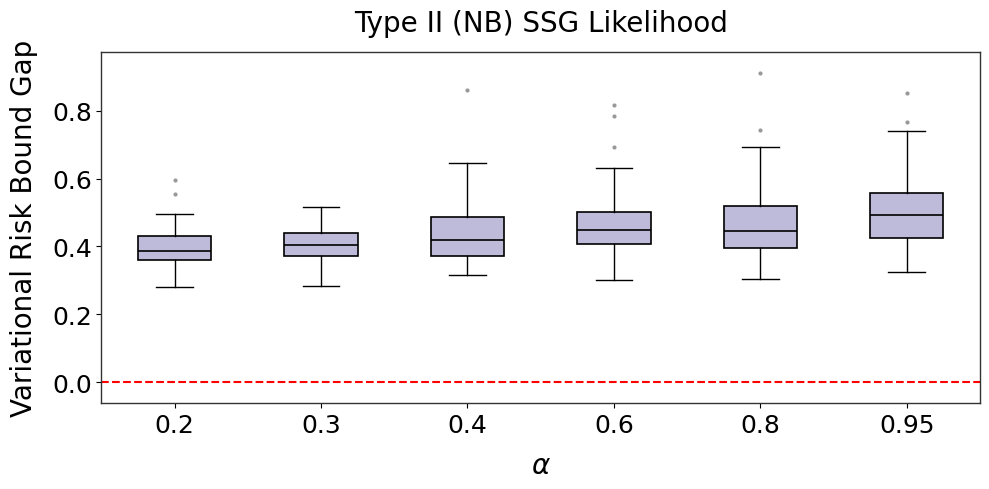

Saved Figure 20 to: results_theory/plots/variational_risk_bound_gap_NB_alpha_less_1_n_2000_p_8.pdf
Figure 21: gap range = [0.05326, 0.2017] | negative gaps = 0/300


/var/folders/ls/s91_zt990n9b6gdbr57m19900000gn/T/ipykernel_47200/2883230770.py:52: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return super().find_class(


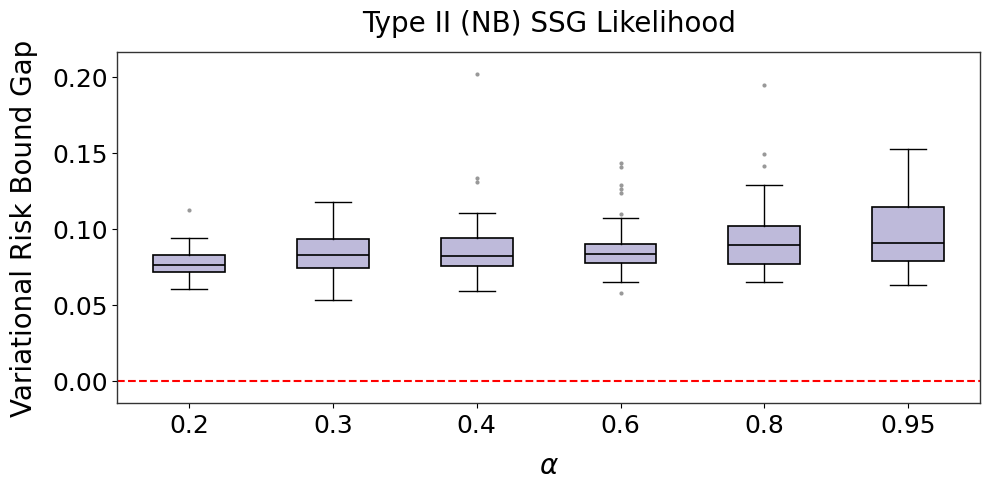

Saved Figure 21 to: results_theory/plots/variational_risk_bound_gap_NB_alpha_less_1_n_10000_p_8.pdf


In [ ]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# FIGURES 20 AND 21 SETTINGS
# ============================================================

output_dir = "results_theory"
plot_dir = os.path.join(
    output_dir,
    "plots",
)

total_p = 9  # total_p = p + 1, where p is the number of covariates (excluding intercept)
p = 8

figure_settings = {
    20: {
        "n": 2000,
    },
    21: {
        "n": 10000,
    },
}

os.makedirs(
    plot_dir,
    exist_ok=True,
)


# ============================================================
# NUMPY PICKLE COMPATIBILITY
#
# Handles files saved with NumPy 2.x when the current
# environment is using NumPy 1.x.
# ============================================================

class NumPyCompatibilityUnpickler(pickle.Unpickler):

    def find_class(self, module, name):
        if module.startswith("numpy._core"):
            module = (
                "numpy.core"
                + module[len("numpy._core"):]
            )

        return super().find_class(
            module,
            name,
        )


def read_numpy_compatible_pickle(path):
    with open(path, "rb") as file:
        return NumPyCompatibilityUnpickler(
            file
        ).load()


# ============================================================
# CREATE ONE NEGATIVE-BINOMIAL FIGURE
# ============================================================

def create_negative_binomial_figure(
    figure_number,
    n,
    p,
    output_dir,
    plot_dir,
):
    # --------------------------------------------------------
    # Input and output paths
    # --------------------------------------------------------

    results_path = os.path.join(
        output_dir,
        (
            "results_NB_theory_alpha_less_1_"
            f"n_{n}_p_{p}.pkl"
        ),
    )

    figure_path = os.path.join(
        plot_dir,
        (
            "variational_risk_bound_gap_"
            "NB_alpha_less_1_"
            f"n_{n}_p_{p}.pdf"
        ),
    )

    # --------------------------------------------------------
    # Load saved simulation results
    # --------------------------------------------------------

    if not os.path.exists(results_path):
        raise FileNotFoundError(
            f"Saved results for Figure {figure_number} "
            f"were not found:\n{results_path}\n"
            f"Run the n={n} Negative-Binomial simulation "
            "cell first."
        )

    results = read_numpy_compatible_pickle(
        results_path
    )

    if not isinstance(results, pd.DataFrame):
        results = pd.DataFrame(
            results
        )

    required_columns = {
        "alpha",
        "bound",
        "integral",
    }

    missing_columns = required_columns.difference(
        results.columns
    )

    if missing_columns:
        raise ValueError(
            f"The Figure {figure_number} results are "
            "missing columns: "
            f"{sorted(missing_columns)}"
        )

    # --------------------------------------------------------
    # Prepare boxplot data
    # --------------------------------------------------------

    df = results.copy()

    df["diff"] = (
        df["bound"]
        - df["integral"]
    )

    alphas = np.sort(
        df["alpha"].dropna().unique()
    )

    if alphas.size == 0:
        raise ValueError(
            f"No non-missing alpha values were found "
            f"for Figure {figure_number}."
        )

    data_by_alpha = []
    kept_alphas = []

    for alpha in alphas:
        values = (
            df.loc[
                df["alpha"] == alpha,
                "diff",
            ]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .to_numpy(dtype=float)
        )

        if values.size == 0:
            print(
                f"[warn] Figure {figure_number}, "
                f"alpha={alpha:g}: "
                "no finite differences; skipping."
            )
            continue

        data_by_alpha.append(
            values
        )

        kept_alphas.append(
            alpha
        )

    if not data_by_alpha:
        raise ValueError(
            f"Every alpha group for Figure "
            f"{figure_number} was empty after removing "
            "NaN and infinite values."
        )

    # --------------------------------------------------------
    # Font sizes
    # --------------------------------------------------------

    label_fontsize = 20
    tick_fontsize = 18
    title_fontsize = 20

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(10, 5),
        facecolor="white",
    )

    bp = ax.boxplot(
        data_by_alpha,
        tick_labels=[
            f"{alpha:g}"
            for alpha in kept_alphas
        ],
        showfliers=True,
        patch_artist=True,
    )

    # --------------------------------------------------------
    # Boxplot style
    # --------------------------------------------------------

    for box in bp["boxes"]:
        box.set(
            facecolor="#BEBADA",
            edgecolor="black",
            linewidth=1.2,
        )

    for median in bp["medians"]:
        median.set(
            color="black",
            linewidth=1.2,
        )

    for artist in (
        bp["whiskers"]
        + bp["caps"]
    ):
        artist.set(
            color="black",
            linewidth=1.0,
        )

    for flier in bp["fliers"]:
        flier.set(
            marker="o",
            markersize=3,
            markerfacecolor="#555555",
            markeredgecolor="none",
            alpha=0.6,
        )

    # --------------------------------------------------------
    # Reference line and axis limits
    # --------------------------------------------------------

    ax.axhline(
        0.0,
        color="red",
        linestyle="--",
        linewidth=1.5,
        zorder=0,
    )

    all_differences = np.concatenate(
        data_by_alpha
    )

    ymin = float(
        all_differences.min()
    )

    ymax = float(
        all_differences.max()
    )

    span = ymax - ymin

    padding = (
        0.1 * span
        if span > 0
        else 0.1 * max(abs(ymax), 1.0)
    )

    ax.set_ylim(
        min(ymin - padding, -padding),
        ymax + padding,
    )

    number_negative = int(
        (all_differences < 0).sum()
    )

    print(
        f"Figure {figure_number}: "
        f"gap range = [{ymin:.4g}, {ymax:.4g}] | "
        f"negative gaps = {number_negative}/"
        f"{all_differences.size}"
    )

    # --------------------------------------------------------
    # Labels and title
    # --------------------------------------------------------

    ax.set_xlabel(
        r"$\alpha$",
        fontsize=label_fontsize,
        labelpad=10,
    )

    ax.set_ylabel(
        "Variational Risk Bound Gap",
        fontsize=label_fontsize,
        labelpad=10,
    )

    ax.set_title(
        "Type II (NB) SSG Likelihood",
        fontsize=title_fontsize,
        pad=15,
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=tick_fontsize,
    )

    ax.set_facecolor(
        "white"
    )

    for spine in ax.spines.values():
        spine.set_color(
            "#333333"
        )

        spine.set_linewidth(
            1.0
        )

    fig.tight_layout()

    # --------------------------------------------------------
    # Save as PDF
    # --------------------------------------------------------

    fig.savefig(
        figure_path,
        format="pdf",
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()
    plt.close(fig)

    print(
        f"Saved Figure {figure_number} to: "
        f"{figure_path}"
    )


# ============================================================
# GENERATE FIGURES 20 AND 21
# ============================================================

for figure_number, settings in figure_settings.items():
    create_negative_binomial_figure(
        figure_number=figure_number,
        n=settings["n"],
        p=p,
        output_dir=output_dir,
        plot_dir=plot_dir,
    )